(sec:1and2dPDFs)=
# One-D and two-D PDFs

\[Note: If there are questions in this section you can't answer right away, come back to them after playing with {ref}`demo:exploring-pdfs`.\]

## To a Bayesian, everything is a PDF

Physicists are used to dealing with PDFs as normalized wave functions squared.  For a one-dimensional particle, the probability density at $x$ is

<span style="color: red">

 $$
 |\Psi(x)|^2 \Longrightarrow p(x) 
 $$

</span> 

The *probability* of finding $x$ in some interval $a \leq x \leq b$ is found by integration:

<span style="color: red">
    
 $$
 \mathbb{P}(a \leq x \leq b) = \int_a^b |\Psi(x)|^2 \; dx 
 $$

</span> 


Just as with "Lagrangian" vs. "Lagrangian density", physicists are not always careful when saying probability vs. probability density.

Physicists are also used to multidimensional normalized PDFs as wave functions squared, e.g. probability density for particle 1 at $x_1$ and particle 2 at $x_2$:

<span style="color: red">

 $$
 |\Psi(x_1, x_2)|^2 \Longrightarrow p(x_1,x_2) \equiv p(\textbf{x})  
   \quad \mbox{with}\quad \textbf{x} 
 \equiv \{x_1,x_2\}
 $$

</span> 

<span style="color:black">(Note that you will find alternative notation in the physics and statistics literature for generic PDFs: $p(\textbf{x}) = P(\textbf{x}) = \textrm{pr}(\textbf{x}) = \textrm{prob}(\textbf{x}) = \ldots$ )</span>

Some other vocabulary and definitions to remember:
* $p(x_1,x_2)$ is the <em>joint probability density</em> of $x_1$ and $x_2$.
* What is the probability to find particle 1 at $x_1$ and particle 2 anywhere?  $\color{blue}{\int\! |\Psi(x_1,x_2)|^2 dx_2}$ (integrated over the full domain of $x_2$, e.g., 0 to $\infty$).
* The <em>marginal probability density</em> of $x_1$ is: 
$\color{blue}{p(x_1) = \int\! p(x_1,x_2)\,dx_2}$.
* "Marginalizing" = "integrating out" (eliminates from the posterior the "nuisance parameters" whose value you don't care about). 

In Bayesian statistics there are PDFs (or PMFs if discrete) for experimental <i>and</i> theoretical uncertainties, fit parameters, hyperparameters (what are those?), events ("Will it rain tomorrow?"), etc.  Even if $x$ has the definite value $x_0$, we can use the PDF $p(x) = \delta(x-x_0)$. 




::::{admonition} Characteristics of PDFs
:class: my-checkpoint
*What are the characteristics (e.g., symmetry, heavy tails, ...) of different pdfs: normal, beta, student t, $\chi^2$, \ldots* 
:::{admonition} Answer 
:class: dropdown, my-answer
**Check these yourself! Note that the answers will often depend on the parameter values for the distribution. A Student t distribution may have "heavy tails" (meaning more probability in the tails than a Gaussian would have) for some parameters but for others it approaches a normal distribution (so by construction no heavy tails).** 
:::
::::


::::{admonition} Sampling
:class: my-checkpoint
*What does sampling mean?* 
:::{admonition} Answer 
:class: dropdown, my-answer
**To sample a given distribution is to draw values with probabilities given by the distribution. In Bayesian inference one is most often sampling a posterior distribution.** 
:::
::::

::::{admonition} Verifying sampling
:class: my-checkpoint
*How do you know if a distribution is correctly sampled?* 
:::{admonition} Answer 
:class: dropdown, my-answer
**One way is to look at the (normalized)histogram. If correctly sampled, this should approximate the distribution and the approximation should improve with more samples.** 
:::
::::


## Visualizing correlated Gaussian distributions

A multivariate Gaussian distribution for $N$ dimensional $\boldsymbol{x} = \{x_1, \ldots, x_N\}$ with $\boldsymbol{\mu} = \{\mu_1, \ldots, \mu_N\}$, with positive-definite *covariance matrix* $\Sigma$ is 

$$
  p(\boldsymbol{x}|\boldsymbol{\mu},\Sigma) = \frac{1}{\sqrt{\det(2\pi\Sigma)}}
    e^{-\frac{1}{2}(\boldsymbol{x}-\boldsymbol{\mu})^\intercal\Sigma^{-1}(\boldsymbol{x}-\boldsymbol{\mu})}
$$

For the one dimensional case, it reduces to the familiar

$$
  p(x_1|\mu_1,\sigma_1) = \frac{1}{\sqrt{2\pi\sigma_1^2}}
    e^{-\frac{(x_1-\mu_1)^2}{2\sigma_1^2}}
$$

with $\Sigma = \sigma_1^2$.

For the bivariate case (two dimensional), 

$$
  \boldsymbol{x} = \pmatrix{x_1\\ x_2} \quad\mbox{and}\quad
  \boldsymbol{\mu} = \pmatrix{\mu_1\\ \mu_2} \quad\mbox{and}\quad
  \Sigma = \pmatrix{\sigma_1^2 & \rho_{12} \sigma_1\sigma_2 \\
                    \rho_{12}\sigma_1\sigma_2 & \sigma_2^2}
        \quad\mbox{with}\ 0 < \rho_{12}^2 < 1            
$$

and $\Sigma$ is positive definite.
The following two *corner plots* are for $\rho_{12} = 0$ and $\rho_{12} = 0.7$.

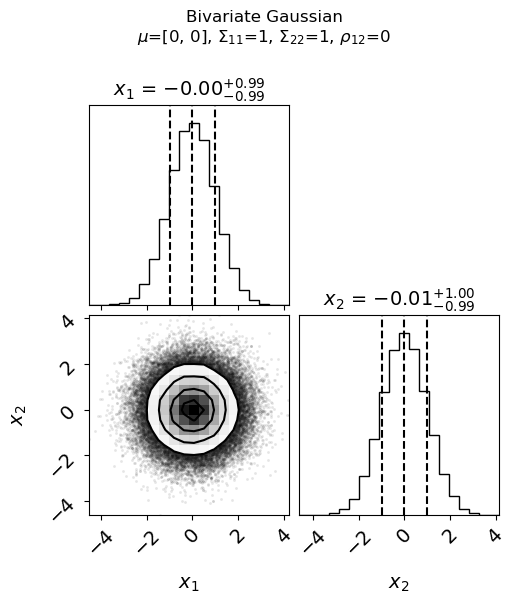

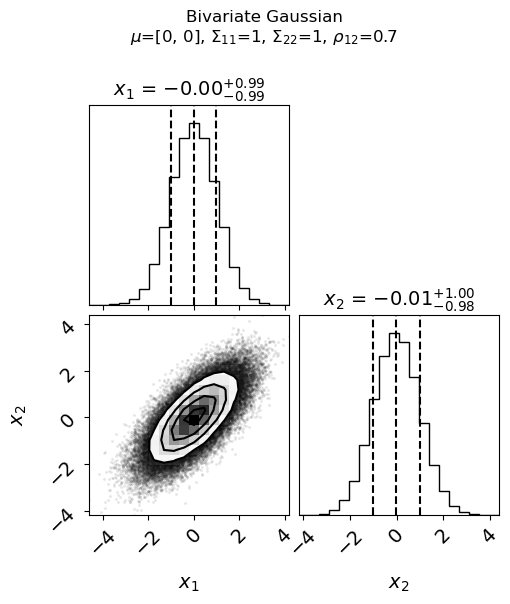

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner

def plot_bivariate_gaussians(mu1, mu2, var1, var2, rho, samples=100000):
    """
    Generates and plots samples from a 2D correlated Gaussian distribution 
    (also known as a bivariate normal distribution).
    
    Args:
        mu1 (float): Mean of the first dimension.
        mu2 (float): Mean of the second dimension.
        var1 (float): Variance of the first dimension.
        var2 (float): Variance of the second dimension.
        rho (float): Correlation coefficient between the dimensions.
    """
    # Create the mean vector and covariance matrix
    mean = np.array([mu1, mu2])
    cov = np.array([
        [var1, rho * np.sqrt(var1 * var2)],
        [rho * np.sqrt(var1 * var2), var2]
    ])

    # Generate samples from the multivariate normal distribution
    try:
        samples = np.random.multivariate_normal(mean, cov, size=samples)
    except np.linalg.LinAlgError:
        print("Invalid covariance matrix. Ensure `var1` and `var2` are positive.")
        return

    # Create the corner plot
    fig = corner.corner(samples, labels=[r'$x_1$', r'$x_2$'], 
                        quantiles=[0.16, 0.5, 0.84], 
                        show_titles=True, 
                        label_kwargs={"fontsize": 14},
                        title_kwargs={"fontsize": 14})
    # Adjust the fonts for the tick labels
    for ax in fig.get_axes():
      ax.tick_params(axis='both', labelsize=14)
    
    # Update the title with the current parameters
    fig.suptitle(
        f"Bivariate Gaussian\n$\mu$=[{mu1}, {mu2}], $\Sigma_{{11}}$={var1}, $\Sigma_{{22}}$={var2}, $\\rho_{{12}}$={rho}", 
        y=1.1)
    plt.show()

mu1 = 0
mu2 = 0
var1 = 1
var2 = 1
rho = 0

plot_bivariate_gaussians(mu1, mu2, var1, var2, rho)

rho = 0.7
plot_bivariate_gaussians(mu1, mu2, var1, var2, rho)

**Questions to consider:**

1. *What does "positive definite" mean and why is this a requirement for the covariance matrix $\Sigma$?*
1. *What is plotted in each part of the graph (called a "corner plot")?*
1. *What effect does changing $\mu_1$ (`mu1`) or $\mu_2$ (`mu2`) have?* 
1. *What effect does changing $\sigma_1$ (`var1`) or $\sigma_2$ (`var2`) have? What if the scales for $x_1$ and $x_2$ were the same?*
1. *What happens if $\rho_{12}$ (`rho`) is equal to $0$ then $+0.5$ then $-0.5$.*
1. *What happens if $\rho_{12}$ (`rho`) is $>1$ or $< -1$? Explain what goes wrong.*
1. *So what characterizes independent (uncorrelated) variables versus positively correlated versus negatively correlated?* 




## Follow-up on correlated posteriors

The first Gaussian 2D pdf in the last section is characterized by elliptical contours of equal probability density whose major axes are aligned with the $x_1$ and $x_2$ axes. 
This is a signature of *independent* random variables.

The second Gaussian 2D pdf had major axes that were slanted with respect to the $x_1$ and $x_2$ axes. 
This is a signature of *correlated* random variables.

Let's look at a case with slanted posteriors and consider analytically (in the next section) what we should expect with correlations.
Use the notebook {ref}`exercise:fitting-a-straight-line-i` as a guide.
* Review the *statistical model*.
* What are we trying to find? $p(\pars|D,I)$, just as in the other notebooks, now with $\pars =[b,m]$.

Comments on the notebook:
* Note that $x_i$ is also randomly distributed uniformly.
* Log likelihood gives fluctuating results whose size depend on the # of data points $N$ and the standard deviation of the noise $dy$.

:::{admonition} Explore!
Play with the notebook and explore how the size varies with $N$ and $dy$.
:::

* Compare priors on the slope $\Longrightarrow$ uniform in $m$ vs. uniform in angle.
* Implementation of plots comparing priors:
::::{admonition} Questions for group discussion
* With the first set of data with $N=20$ points, does the prior matter?
* With the second set of data with $N=3$ points, does the prior matter?
:::{admonition} Answers
:class: dropdown
No!  
Yes!
:::
::::
* Note: log(posterior) = log(likelihood) + log(prior)
    * Maximum is set to 1 for plotting
    * Exponentiate: posterior = exp(log(posterior))

::::{admonition} Recap: what does it mean that the ellipses are slanted? And why is it expected?
:::{admonition} Answer
:class: dropdown
It means that the slope and intercept are *correlated*. Intuitively, if we want to maintain a good fit when we change the slope, we will need to change the intercept as well. They are not independent!
:::
::::

* Observations about the second set of data: 
    * True answers are intercept $b = 25.0$, slope $m=0.5$.
    * Flat prior gives $b = -50 \pm 75$, $m = 1.5 \pm 1$, so barely at the $1\sigma$ level.
    * Symmetric prior gives $b = 25 \pm 50$, $m = 0.5 \pm 0.75$, so much better.
    * Distributions are wide (not surprising since only three points!).

## 2D PDF with a quadratic approximation

Consider the cartoon of a two-dimensional PDF $L(X,Y)$. We'll analyze it in a quadratic approximation.

```{image} ../assets/posterior_ellipse_cartoon.png
:alt: posterior ellipse
:class: bg-primary
:width: 300px
:align: left
```
First, find $X_0$, $Y_0$ (best estimate) by differentiating

$$\begin{align}
 L(X,Y) &= \log p(X,Y|\{\text{data}\}, I) \\
  \quad&\Longrightarrow\quad
  \left.\frac{dL}{dX}\right|_{X_0,Y_0} = 0, \ 
  \left.\frac{dL}{dY}\right|_{X_0,Y_0} = 0
\end{align}$$

To check reliability, Taylor expand around $L(X_0,Y_0)$:

$$\begin{align}
 L &= L(X_0,Y_0) + \frac{1}{2}\Bigl[
   \left.\frac{\partial^2L}{\partial X^2}\right|_{X_0,Y_0}(X-X_0)^2
  + \left.\frac{\partial^2L}{\partial Y^2}\right|_{X_0,Y_0}(Y-Y_0)^2 \\
  & \qquad\qquad\qquad + 2 \left.\frac{\partial^2L}{\partial X\partial Y}\right|_{X_0,Y_0}(X-X_0)(Y-Y_0)
   \Bigr] + \ldots \\
   &\equiv L(X_0, Y_0) + \frac{1}{2}Q + \ldots
\end{align}$$

It makes sense to do this in (symmetric) matrix notation:

$$
  Q = 
  \begin{pmatrix} X-X_0 & Y-Y_0 
  \end{pmatrix}
  \begin{pmatrix} A & C \\
                  C & B 
  \end{pmatrix}
  \begin{pmatrix} X-X_0 \\
                  Y-Y_0 
  \end{pmatrix}
$$

$$
 \Longrightarrow
 A = \left.\frac{\partial^2L}{\partial X^2}\right|_{X_0,Y_0},
 \quad
 B = \left.\frac{\partial^2L}{\partial Y^2}\right|_{X_0,Y_0},
 \quad
 C = \left.\frac{\partial^2L}{\partial X\partial Y}\right|_{X_0,Y_0}
$$

* So in quadratic approximation, the contour $Q=k$ for some $k$ is an ellipse centered at $X_0, Y_0$. The orientation and eccentricity are determined by $A$, $B$, and $C$.

* The principal axes are found from the eigenvectors of the Hessian matrix $\begin{pmatrix} A & C \\ C & B  \end{pmatrix}$.

$$
\begin{pmatrix}
     A & C \\
     C & B
\end{pmatrix}
\begin{pmatrix}
 x \\ y
\end{pmatrix}
=
\lambda
\begin{pmatrix}
 x \\ y
\end{pmatrix}
\quad\Longrightarrow\quad
\lambda_1,\lambda_2 < 0 \ \mbox{so $(x_0,y_0)$ is a maximum}
$$

* What if the ellipse is skewed?

```{image} ../assets/skewed_ellipse_cartoon.png
:alt: posterior ellipse
:class: bg-primary
:width: 500px
:align: center
```

Look at the correlation matrix

$$
 \begin{pmatrix}
 \sigma_x^2 & \sigma^2_{xy} \\
 \sigma^2_{xy} & \sigma_y^2
 \end{pmatrix}
 = - \begin{pmatrix}
     A & C \\
     C & B
     \end{pmatrix}^{-1}
$$


<!--
## Sivia example on "signal on top of background"

See {cite}`Sivia2006` for further details. The figure shows the set up:
```{image} ../assets/signal_on_background_handdrawn.png
:alt: signal on background
:class: bg-primary
:width: 500px
:align: center
```
The level of the background is $B$, the peak height of the signal above the background is $A$ and there are $\{N_k\}$ counts in the bins $\{x_k\}$. 
The distribution is

$$
  D_k = n_0 [A e^{-(x_k-x_0)^2/2w^2} + B]
$$


**Goal:** Given $\{N_k\}$, find $A$ and $B$.

So what is the posterior we want?

$$
  p(A,B | \{N_k\}, I) \ \mbox{with $I=x_0, w$, Gaussian, flat background}  
$$

The actual counts we get will be integers, and we can expect a *Poisson distribution*:

$$
   p(n|\mu) = \frac{\mu^n e^-\mu}{n!} \ \mbox{$n\geq 0$ integer}
$$

or, with $n\rightarrow N_k$, $\mu \rightarrow D_k$,

$$
  p(N_k|D_k) = \frac{D_k e^{-D_k}}{N_k!}
$$

for the $k^{\text{th}}$ bin at $x_k$.

What do we learn from the plots of the Poisson distribution?

$$\begin{align}
  p(A,B | \{N_k\}, I) &\propto p(\{N_k\}|A,B,I) \times p(A,B|I) \\
  \textit{posterior}\qquad &\propto \quad\textit{likelihood}\quad \times \quad\textit{prior}
\end{align}$$

which means that 

$$
  L = \log[p(A,B)|\{N_k\,I\})] = \text{constant} + \sum_{k=1}^M [N_k \log(D_k) - D_k]
$$


* Choose the constant for convenience; it is independent of $A,B$.
* Best *point estimate*: maximize $L(A,B)$ to find $A_0,B_0$
* Look at code for likelihood and prior
* Uniform (flat) prior for $0 \leq A \leq A_{\text{max}}$, $0 < B \leq B_{\text{max}}$
    * Not sensitive to $A_{\text{max}}$, $B_{\text{max}}$ if larger than support of likelihood

:::{admonition} Table of results

| Fig. # | data bins  | $\Delta x$  | $(x_k)_{\text{max}}$ | $D_{\text{max}}$ |
|:----:|:----:|:----:|:----:|:----:|
|  1  |  15  |  1   |   7   | 100  |
|  2  |  15  |  1   |   7   | 10   |
|  3  |  31  |  1   |  15   | 100  |
|  4  |   7  |  1   |   3   | 100  |

:::

Comments on figures:
* Figure 1: 15 bins and $D_{\text{max}} = 100$
    * Contours are at 20% intervals showing *height*
    * Read off best estimates and compare to true
        * does find signal is about half background
    * Marginalization of $B$
        * What if we don't care about $B$? ("nuisance parameter")

        $$
         p(A | \{N_k\}, I) \int_0^\infty p(A,B|\{N_k\},I)\, dB
        $$
 
        * compare to $p(A | \{N_k\}, B_{\text{true}}, I)$
          $\Longrightarrow$ plotted on graph
    * Also can marginalize over $A$

        $$
         p(B | \{N_k\}, I) \int_0^\infty p(A,B|\{N_k\},I)\, dA
        $$

    * Note how these are done in code: `B_marginalized` and `B_true_fixed`, and note the normalization at the end.

* Set extra plots to true
    * different representations of the same info and contours in the first three. The last one is an attempt at 68%, 95%, 99.7% (but looks wrong).
    * note the difference between contours showing the pdf *height* and showing the integrated volume.

* Look at the other figures and draw conclusions.

* How should you design your experiments?
    * E.g., how should you bin data, how many counts are needed, what $(x_k)_{\text{max}}$, and so on.    
-->

## Compare Gaussian noise sampling to lighthouse calculation

Jump to the Bayesian approach in {ref}`exercise:gaussian-noise-and-averages-ii` and then come back to contrast with the frequentist approach.
The goal is to sample a posterior $p(\pars|D,I)$

$$
         p(\mu,\sigma | D, I) \leftrightarrow p(x_0,y_0|X,I)
$$

where $D$ on the left are the $x$ points and $D$ on the right are the $\{x_k\}$ where flashes hit.

What do we need? From Bayes' theorem, we need 

$$\begin{align}
      \text{likelihood:}& \quad p(D|\mu,\sigma,I) \leftrightarrow p(D|x_0,y_0,I) \\
      \text{prior:}& \quad p(\mu,\sigma|I) \leftrightarrow p(x_0,y_0|I)
\end{align}$$

You are generalizing the functions for log pdfs and the plotting of posteriors that are in notebook {ref}`exercise:radioactive-lighthouse-problem`.
Note in {ref}`exercise:gaussian-noise-and-averages-ii` the functions for log-prior and log-likelihood.
* Here $\pars = [\mu,\sigma]$ is a vector of parameters; cf.  $\pars = [x_0,y_0]$.
* Step through the set up for `emcee`.
    * It is best to create an environment that will include `emcee` and `corner`. 
    :::{hint} Nothing in the `emcee` sampling part needs to change!
    ::: 
    * More later on what is happening, but basically we are doing 50 random walks in parallel to explore the posterior. Where the walkers end up will define our samples of $\mu,\sigma$
    $\Longrightarrow$ the histogram *is* an approximation to the (unnormalized) joint posterior.
    * Plotting is also the same, once you change labels and `mu_true`, `sigma_true` to `x0_true`, `y0_true`. (And skip the `maxlike` part.)
* Analysis:
    * Maximum likelihood here is the frequentist estimate $\longrightarrow$ this is an optimization problem.
    ::::{admonition} Question
    Are $\mu$ and $\sigma$ correlated or uncorrelated?
    :::{admonition} Answer
    :class: dropdown 
    They are *uncorrelated* because the contour ellipses in the joint posterior have their major and minor axes parallel to the $\mu$ and $\sigma$ axes. Note that the fact that they look like circles is just an accident of the ranges chosen for the axes; if you changed the $\sigma$ axis range by a factor of two, the circle would become flattened.
    :::
    ::::
    * Read off marginalized estimates for $\mu$ and $\sigma$.